# DIV2K full — RD comparisons (Nina / Swin × direct / ADMM)

Mean over images for each $\lambda$: Bpp vs PSNR of compressed SR vs GT.

| Curve set | Directory | Tag suffix |
|-----------|-----------|------------|
| Nina direct | `runs/bitrate_sr_nina_full` | `_direct` |
| Nina ADMM | `runs/bitrate_sr_nina_admm` | `_admm` |
| Swin direct | `runs/bitrate_sr_swin` | `_direct` |
| Swin ADMM | `runs/bitrate_sr_swin_admm` | `_admm` |

Partial runs (e.g. ADMM still finishing) still plot from available `metrics.json`.

In [1]:
from pathlib import Path
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path("/gpfs/gpfs0/timofey.glukhikh/Science_Phan")
if not PROJECT.exists():
    PROJECT = Path("/gpfs/data/gpfs0/timofey.glukhikh/Science_Phan")

RUNS = PROJECT / "runs"
OUT_DIR = RUNS / "rd_compare"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# (label, runs_dir, backbone, method_tag)
SERIES = {
    "nina_direct": (RUNS / "bitrate_sr_nina_full", "nina", "direct"),
    "nina_admm": (RUNS / "bitrate_sr_nina_admm", "nina", "admm"),
    "swin_direct": (RUNS / "bitrate_sr_swin", "swin", "direct"),
    "swin_admm": (RUNS / "bitrate_sr_swin_admm", "swin", "admm"),
}

LAMS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]


def load_mean_rd(root: Path, backbone: str, method: str):
    """Return (lams, mean_bpp, mean_psnr, n_per_lam) sorted by lambda."""
    by_lam: dict[float, list[tuple[float, float]]] = defaultdict(list)
    if not root.exists():
        return [], [], [], []

    pat = f"img*_{backbone}_psnr35_lam*_r4_{method}"
    for d in root.glob(pat):
        mf = d / "metrics.json"
        if not mf.exists():
            continue
        m = json.loads(mf.read_text())
        lam, bpp, psnr = m.get("lambda"), m.get("Bpp"), m.get("PSNR_cmpref")
        if lam is None or bpp is None or psnr is None:
            continue
        by_lam[float(lam)].append((float(bpp), float(psnr)))

    lams = sorted(by_lam.keys())
    xs, ys, ns = [], [], []
    for lam in lams:
        pts = by_lam[lam]
        xs.append(float(np.mean([p[0] for p in pts])))
        ys.append(float(np.mean([p[1] for p in pts])))
        ns.append(len(pts))
    return lams, xs, ys, ns


def cache_all():
    data = {}
    for key, (root, backbone, method) in SERIES.items():
        lams, xs, ys, ns = load_mean_rd(root, backbone, method)
        data[key] = {"root": root, "lams": lams, "bpp": xs, "psnr": ys, "n": ns}
        n_dirs = len(list(root.glob(f"img*_{backbone}_*_{method}"))) if root.exists() else 0
        print(
            f"{key:12s}  exists={root.exists()}  dirs≈{n_dirs:5d}  "
            f"λ points={len(lams)}  n/λ={ns if ns else '-'}"
        )
    return data


DATA = cache_all()

nina_direct   exists=True  dirs≈ 6400  λ points=8  n/λ=[800, 800, 800, 800, 800, 800, 800, 800]
nina_admm     exists=True  dirs≈ 1301  λ points=8  n/λ=[178, 125, 173, 120, 174, 174, 175, 174]
swin_direct   exists=True  dirs≈ 6271  λ points=8  n/λ=[800, 800, 800, 800, 800, 800, 800, 670]
swin_admm     exists=False  dirs≈    0  λ points=0  n/λ=-


In [2]:
STYLES = {
    "nina_direct": ("o-", "C0", "Nina direct"),
    "nina_admm": ("s--", "C1", "Nina ADMM"),
    "swin_direct": ("^-.", "C2", "Swin direct"),
    "swin_admm": ("d:", "C3", "Swin ADMM"),
}


def plot_compare(keys: list[str], title: str, save_name: str):
    fig, ax = plt.subplots(figsize=(7.5, 5))
    any_curve = False
    for key in keys:
        d = DATA[key]
        if not d["lams"]:
            print(f"skip {key}: no metrics yet")
            continue
        any_curve = True
        fmt, color, label = STYLES[key]
        # sort by bpp for a proper RD polyline
        order = np.argsort(d["bpp"])
        xs = [d["bpp"][i] for i in order]
        ys = [d["psnr"][i] for i in order]
        lams = [d["lams"][i] for i in order]
        ax.plot(xs, ys, fmt, color=color, markersize=8, label=f"{label} (n≈{max(d['n'])})")
        for x, y, lam in zip(xs, ys, lams):
            ax.annotate(
                f"λ={lam:g}",
                (x, y),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=7,
                color=color,
            )
    ax.set_xlabel("Bpp (mean over images)")
    ax.set_ylabel("PSNR vs GT compressed (mean)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if any_curve:
        ax.legend()
    out = OUT_DIR / save_name
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out}")
    plt.show()
    plt.close(fig)


## 1. Nina: direct vs ADMM

Saved -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/rd_compare/rd_nina_direct_vs_admm.png


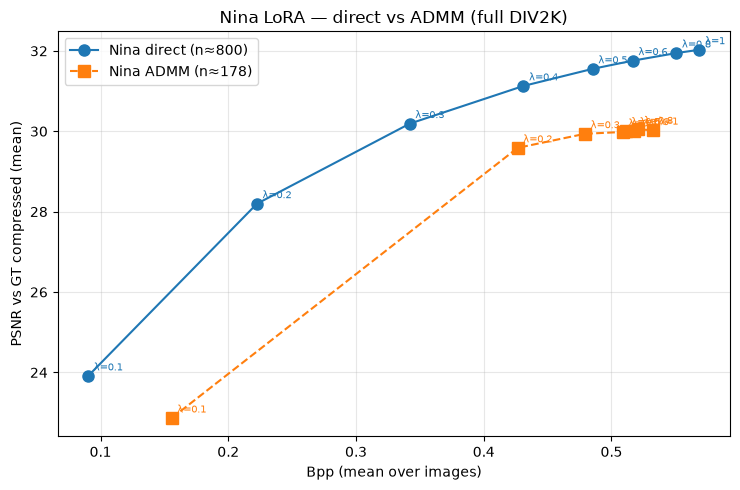

In [3]:
plot_compare(
    ["nina_direct", "nina_admm"],
    title="Nina LoRA — direct vs ADMM (full DIV2K)",
    save_name="rd_nina_direct_vs_admm.png",
)

## 2. Swin: direct vs ADMM

skip swin_admm: no metrics yet
Saved -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/rd_compare/rd_swin_direct_vs_admm.png


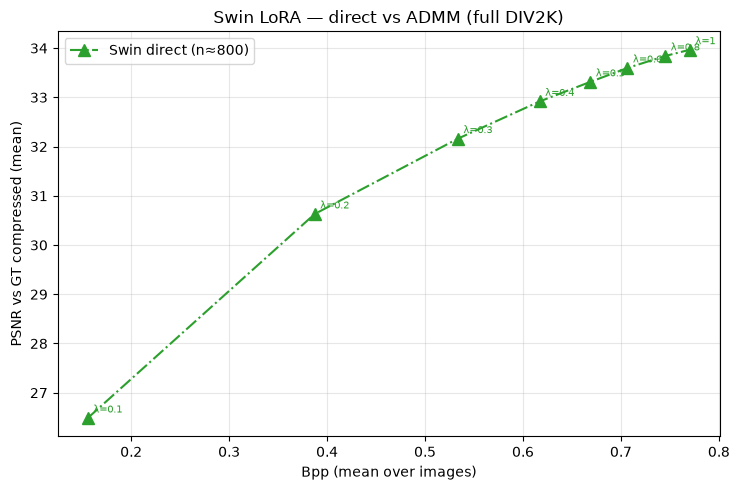

In [4]:
plot_compare(
    ["swin_direct", "swin_admm"],
    title="Swin LoRA — direct vs ADMM (full DIV2K)",
    save_name="rd_swin_direct_vs_admm.png",
)

## 3. Direct: Nina vs Swin

Saved -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/rd_compare/rd_direct_nina_vs_swin.png


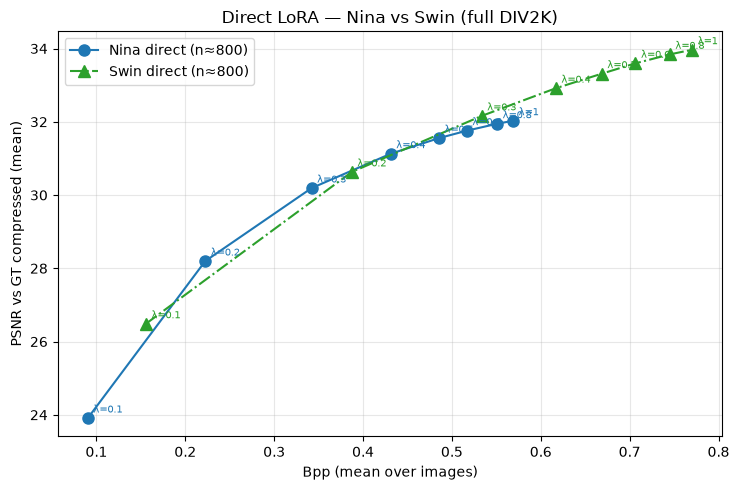

In [5]:
plot_compare(
    ["nina_direct", "swin_direct"],
    title="Direct LoRA — Nina vs Swin (full DIV2K)",
    save_name="rd_direct_nina_vs_swin.png",
)

## 4. ADMM: Nina vs Swin

skip swin_admm: no metrics yet
Saved -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/rd_compare/rd_admm_nina_vs_swin.png


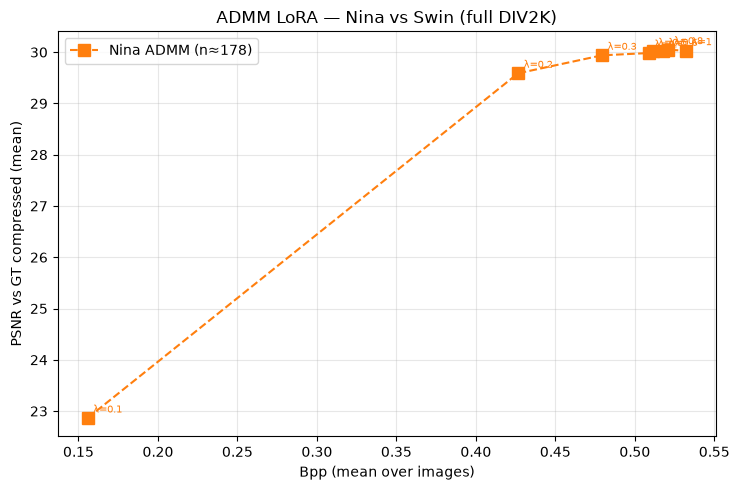

In [6]:
plot_compare(
    ["nina_admm", "swin_admm"],
    title="ADMM LoRA — Nina vs Swin (full DIV2K)",
    save_name="rd_admm_nina_vs_swin.png",
)

## Optional: all four on one axes

skip swin_admm: no metrics yet
Saved -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/rd_compare/rd_all_nina_swin_direct_admm.png


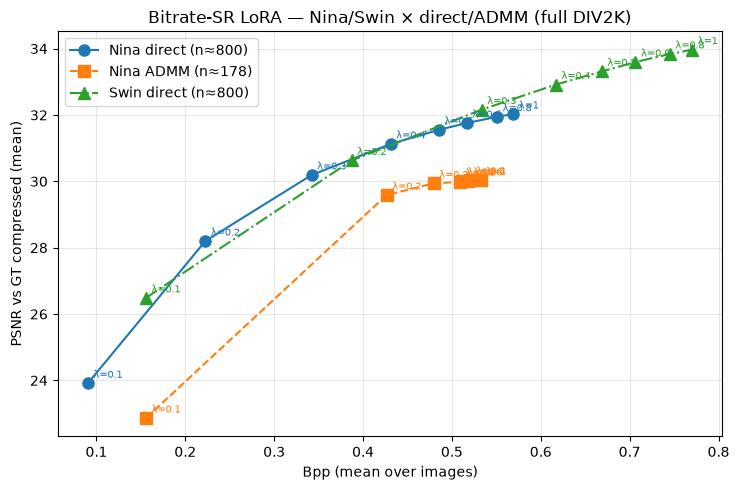

In [7]:
plot_compare(
    ["nina_direct", "nina_admm", "swin_direct", "swin_admm"],
    title="Bitrate-SR LoRA — Nina/Swin × direct/ADMM (full DIV2K)",
    save_name="rd_all_nina_swin_direct_admm.png",
)